In [ ]:
print("hello")

hello


In [1]:
!git clone https://github.com/WhoIsElijah233/speech-emotion-recognition.git

Cloning into 'speech-emotion-recognition'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 85 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 160.20 KiB | 6.96 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [ ]:
%cd speech-emotion-recognition

/content/speech-emotion-recognition


In [ ]:
%ls -l

total 12
drwxr-xr-x 2 root root 4096 Mar 22 01:36 notebooks/
-rw-r--r-- 1 root root  252 Mar 22 01:36 README.md
drwxr-xr-x 2 root root 4096 Mar 22 01:36 src/


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

data_path = "/content/drive/MyDrive/emotion_dataset"
os.makedirs(data_path, exist_ok=True)

print("数据路径：", data_path)

数据路径： /content/drive/MyDrive/emotion_dataset


In [ ]:
import torch
import os

fake_data_path = os.path.join(data_path, "fake_data")
os.makedirs(fake_data_path, exist_ok=True)

for i in range(100):
  waveform = torch.randn(1, 16000)
  label = torch.randint(0, 4, (1,))

  torch.save((waveform, label), f"{fake_data_path}/{i}.pt")

print("假数据生成完成")

假数据生成完成


In [ ]:
path = "/content/drive/MyDrive/emotion_dataset/fake_data/0.pt"

import torch

data = torch.load(path)

print(type(data))
print(data)

<class 'tuple'>
(tensor([[-0.7730,  0.9142,  0.7770,  ...,  0.7458,  0.2562, -0.3265]]), tensor([1]))


In [ ]:
# 编写好dataset文件后进行测试
%ls -l
from src.dataset import EmotionDataset

dataset = EmotionDataset(fake_data_path)

print(len(dataset))
print(dataset)
# waveform, label = torch.load(fake_data_path)
x, y = dataset[1]
print(x.shape)
print(y.shape)

total 12
drwxr-xr-x 2 root root 4096 Mar 22 01:36 notebooks/
-rw-r--r-- 1 root root  252 Mar 22 01:36 README.md
drwxr-xr-x 3 root root 4096 Mar 22 02:33 src/
100


NameError: name 'waveform' is not defined

In [ ]:
import importlib
import src.dataset
importlib.reload(src.dataset)
from src.dataset import EmotionDataset

dataset = EmotionDataset()

print(len(dataset))

audio, label = dataset[0]

print(audio.shape)
print(label)

100
torch.Size([16000])
2


In [ ]:
# 测试dataloader

from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for audio, label in loader:
  print(audio.shape)
  print(label.shape)
  break

torch.Size([4, 16000])
torch.Size([4])


In [ ]:
from src.model import EmotionModel

model = EmotionModel()

print(model)

EmotionModel(
  (fc1): Linear(in_features=16000, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
x = torch.randn(4, 16000)

y = model(x)

print(y.shape)

torch.Size([4, 4])


In [6]:
!python /content/speech-emotion-recognition/src/train.py

dataloader ready
model ready
start training. . .
Epoch 1: model saved. accuracy: 0.2824
Epoch 1 - Loss: 2.7122, val_acc: 0.2824, test_acc: 0.2535
Epoch 2: model saved. accuracy: 0.3056
Epoch 2 - Loss: 1.7426, val_acc: 0.3056, test_acc: 0.2719
Epoch 3: model saved. accuracy: 0.3287
Epoch 3 - Loss: 1.5465, val_acc: 0.3287, test_acc: 0.3134
Epoch 4: model saved. accuracy: 0.3519
Epoch 4 - Loss: 1.4360, val_acc: 0.3519, test_acc: 0.3272
Epoch 5: model saved. accuracy: 0.3750
Epoch 5 - Loss: 1.3185, val_acc: 0.3750, test_acc: 0.3410
Epoch 6 - Loss: 1.4943, val_acc: 0.3333, test_acc: 0.3364
Epoch 7: model saved. accuracy: 0.3796
Epoch 7 - Loss: 1.2880, val_acc: 0.3796, test_acc: 0.3364
Epoch 8 - Loss: 1.0922, val_acc: 0.3657, test_acc: 0.3594
Epoch 9: model saved. accuracy: 0.4120
Epoch 9 - Loss: 0.9364, val_acc: 0.4120, test_acc: 0.3917
Epoch 10: model saved. accuracy: 0.4306
Epoch 10 - Loss: 0.8062, val_acc: 0.4306, test_acc: 0.3871
Epoch 11 - Loss: 0.9152, val_acc: 0.4028, test_acc: 0.387

In [ ]:
%ls -l

total 96
drwx------ 2 root root 4096 Mar 22  2018 Actor_01/
drwx------ 2 root root 4096 Mar 22  2018 Actor_02/
drwx------ 2 root root 4096 Mar 22  2018 Actor_03/
drwx------ 2 root root 4096 Mar 22  2018 Actor_04/
drwx------ 2 root root 4096 Mar 22  2018 Actor_05/
drwx------ 2 root root 4096 Mar 22  2018 Actor_06/
drwx------ 2 root root 4096 Mar 22  2018 Actor_07/
drwx------ 2 root root 4096 Mar 22  2018 Actor_08/
drwx------ 2 root root 4096 Mar 22  2018 Actor_09/
drwx------ 2 root root 4096 Mar 22  2018 Actor_10/
drwx------ 2 root root 4096 Mar 22  2018 Actor_11/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_12/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_13/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_14/
drwx------ 2 root root 4096 Mar 22  2018 Actor_15/
drwx------ 2 root root 4096 Mar 22  2018 Actor_16/
drwx------ 2 root root 4096 Mar 22  2018 Actor_17/
drwx------ 2 root root 4096 Mar 22  2018 Actor_18/
drwx------ 2 root root 4096 Mar 22  2018 Actor_19/
drwx------ 2 root root

In [ ]:
%cd ..
%ls -l

/content/drive/MyDrive/emotion_dataset
total 8
drwx------  2 root root 4096 Mar 22 01:41 fake_data/
drwx------ 26 root root 4096 Mar 22 03:22 RAVDESS/


torch.Size([1, 158558])
48000
torch.Size([1, 80, 793])


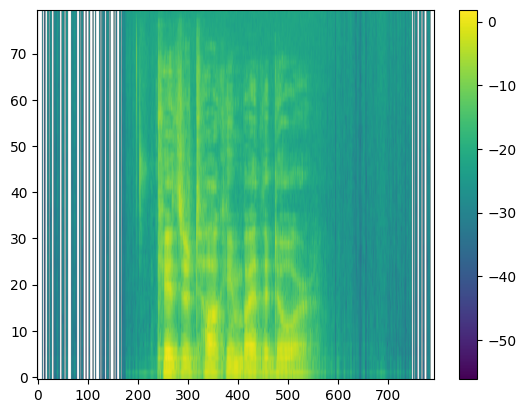

In [ ]:
import torchaudio
import os

root = "RAVDESS"

actor = os.listdir(root)[0]

path = os.path.join(root, actor, os.listdir(os.path.join(root, actor))[0])

waveform, sr = torchaudio.load(path)

print(waveform.shape)
print(sr)

import torchaudio.transforms as T

mel = T.MelSpectrogram(
    sample_rate=16000,
    n_mels=80
)

spec = mel(waveform)

print(spec.shape)

import matplotlib.pyplot as plt

plt.imshow(spec[0].log2().numpy(), aspect="auto", origin="lower")
plt.colorbar()
plt.show()

In [ ]:
%pwd

'/content/drive/MyDrive/emotion_dataset'

In [ ]:
%cd /content/speech-emotion-recognition/src

/content/speech-emotion-recognition/src


In [ ]:
import importlib
import dataset
importlib.reload(dataset)
from dataset import EmotionDataset

dataset = EmotionDataset()

print("dataset size:", len(dataset))

x, y = dataset[0]

print("spectrogram shape:", x.shape)
print("label:", y)

dataset size: 1440
spectrogram shape: torch.Size([1, 80, 300])
label: 0


In [ ]:
from model import EmotionCNN
import torch

model = EmotionCNN()

x = torch.randn(4, 1, 80, 300)

y = model(x)

print(y.shape)

torch.Size([4, 8])


In [ ]:
!python train.py

epoch: 0 loss: 2.32343334224489
epoch: 1 loss: 1.6804325037532382


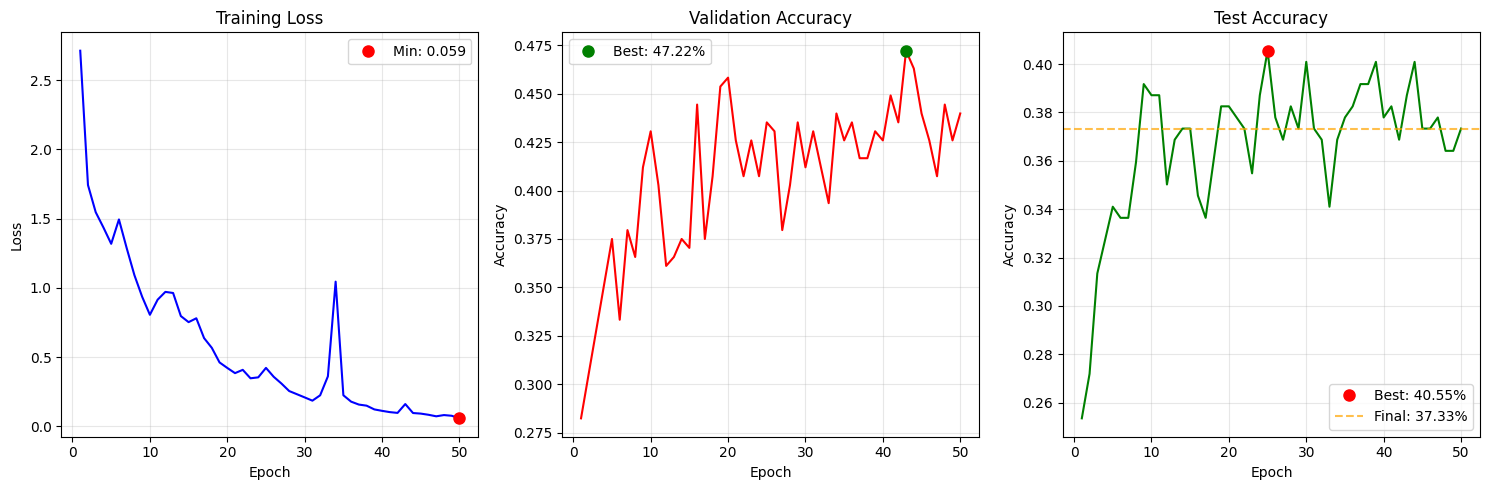


训练结果统计
最佳验证准确率: 47.22% (第43轮)
最佳测试准确率: 40.55% (第25轮)
最终测试准确率: 37.33%
最低训练损失: 0.0588 (第50轮)

结果已保存到 baseline_results.json
损失曲线已保存到 training_curves.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 从你的训练输出中，我可以看到这些数据：
# 根据你的日志，我推断出这些数值（大致）

# 如果你在训练过程中记录了变量，直接用：
if 'train_losses' in locals() and 'val_accuracies' in locals():
    # 直接用已有的变量
    losses = train_losses
    val_accs = val_accuracies
    test_accs = test_accuracies if 'test_accuracies' in locals() else None
else:
    # 如果没有保存变量，从你的日志手动输入关键数据
    # 根据你的输出，提取的关键数据：
    epochs = list(range(1, 51))  # 1-50轮

    # 从日志提取的验证准确率（每轮）
    val_accs = [
        0.2824, 0.3056, 0.3287, 0.3519, 0.3750, 0.3333, 0.3796, 0.3657, 0.4120, 0.4306,
        0.4028, 0.3611, 0.3657, 0.3750, 0.3704, 0.4444, 0.3750, 0.4074, 0.4537, 0.4583,
        0.4259, 0.4074, 0.4259, 0.4074, 0.4352, 0.4306, 0.3796, 0.4028, 0.4352, 0.4120,
        0.4306, 0.4120, 0.3935, 0.4398, 0.4259, 0.4352, 0.4167, 0.4167, 0.4306, 0.4259,
        0.4491, 0.4352, 0.4722, 0.4630, 0.4398, 0.4259, 0.4074, 0.4444, 0.4259, 0.4398
    ]

    # 从日志提取的训练损失（每轮）
    losses = [
        2.7122, 1.7426, 1.5465, 1.4360, 1.3185, 1.4943, 1.2880, 1.0922, 0.9364, 0.8062,
        0.9152, 0.9716, 0.9635, 0.7970, 0.7532, 0.7810, 0.6381, 0.5677, 0.4623, 0.4226,
        0.3851, 0.4089, 0.3479, 0.3546, 0.4229, 0.3586, 0.3099, 0.2558, 0.2329, 0.2099,
        0.1864, 0.2251, 0.3619, 1.0454, 0.2254, 0.1793, 0.1582, 0.1503, 0.1233, 0.1129,
        0.1037, 0.0981, 0.1619, 0.0972, 0.0930, 0.0845, 0.0735, 0.0824, 0.0774, 0.0588
    ]

    # 从日志提取的测试准确率（每轮）
    test_accs = [
        0.2535, 0.2719, 0.3134, 0.3272, 0.3410, 0.3364, 0.3364, 0.3594, 0.3917, 0.3871,
        0.3871, 0.3502, 0.3687, 0.3733, 0.3733, 0.3456, 0.3364, 0.3594, 0.3825, 0.3825,
        0.3779, 0.3733, 0.3548, 0.3871, 0.4055, 0.3779, 0.3687, 0.3825, 0.3733, 0.4009,
        0.3733, 0.3687, 0.3410, 0.3687, 0.3779, 0.3825, 0.3917, 0.3917, 0.4009, 0.3779,
        0.3825, 0.3687, 0.3871, 0.4009, 0.3733, 0.3733, 0.3779, 0.3641, 0.3641, 0.3733
    ]

# 画图
plt.figure(figsize=(15, 5))

# 子图1：损失曲线
plt.subplot(1, 3, 1)
plt.plot(range(1, len(losses)+1), losses, 'b-', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
# 标记最低点
min_loss_idx = losses.index(min(losses))
plt.plot(min_loss_idx+1, min(losses), 'ro', markersize=8, label=f'Min: {min(losses):.3f}')
plt.legend()

# 子图2：验证集准确率
plt.subplot(1, 3, 2)
plt.plot(range(1, len(val_accs)+1), val_accs, 'r-', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.grid(True, alpha=0.3)
# 标记最佳点
best_val_idx = val_accs.index(max(val_accs))
plt.plot(best_val_idx+1, max(val_accs), 'go', markersize=8, label=f'Best: {max(val_accs)*100:.2f}%')
plt.legend()

# 子图3：测试集准确率
plt.subplot(1, 3, 3)
plt.plot(range(1, len(test_accs)+1), test_accs, 'g-', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.grid(True, alpha=0.3)
# 标记最佳点
best_test_idx = test_accs.index(max(test_accs))
plt.plot(best_test_idx+1, max(test_accs), 'ro', markersize=8, label=f'Best: {max(test_accs)*100:.2f}%')
plt.axhline(y=0.3733, color='orange', linestyle='--', alpha=0.7, label=f'Final: 37.33%')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印统计信息
print("\n" + "="*50)
print("训练结果统计")
print("="*50)
print(f"最佳验证准确率: {max(val_accs)*100:.2f}% (第{best_val_idx+1}轮)")
print(f"最佳测试准确率: {max(test_accs)*100:.2f}% (第{best_test_idx+1}轮)")
print(f"最终测试准确率: {test_accs[-1]*100:.2f}%")
print(f"最低训练损失: {min(losses):.4f} (第{min_loss_idx+1}轮)")
print("="*50)

# 保存结果到文件
import json
results = {
    'best_val_accuracy': max(val_accs),
    'best_val_epoch': best_val_idx + 1,
    'best_test_accuracy': max(test_accs),
    'best_test_epoch': best_test_idx + 1,
    'final_test_accuracy': test_accs[-1],
    'min_train_loss': min(losses),
    'all_val_accuracies': val_accs,
    'all_test_accuracies': test_accs,
    'all_train_losses': losses
}

with open('baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n结果已保存到 baseline_results.json")
print("损失曲线已保存到 training_curves.png")